In [1]:
import os

In [2]:
os.environ["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=1 inter_op_parallelism_threads=1"

In [3]:
from jax import config as jconf

In [4]:
jconf.update("jax_enable_x64", True)

In [5]:
import jax
from jax import numpy as jnp
import numpy as np
from jax import jit, grad, lax

import pandas as pd

from jax.experimental import sparse as jsparse
from scipy import sparse

In [6]:
class M:

    def __init__(self, n):
        self.ncomps = n
        self._fsource_indices = []
        self._fdest_indices = []
        self._frates = []

    def add_flow(self, sidx, didx, rate):
        self._fsource_indices.append(sidx)
        self._fdest_indices.append(didx)
        self._frates.append(rate)

    def add_multiflow(self, sidx, didx, rate):
        self._fsource_indices = sidx
        self._fdest_indices = didx
        self._frates = rate

    def _build_coo_(self):
        src = np.concat([self._fsource_indices, self._fsource_indices])
        dst = np.concat([self._fdest_indices, self._fsource_indices])
        indices = np.array([dst, src]).T
        rates = jnp.concat([self._frates, -1.0 * self._frates])
        #mat = jnp.empty((self.ncomps, self.ncomps))
        #mat = mat.at[dst,src].set(rates)
        mat = jsparse.BCOO((rates, indices), shape=(self.ncomps, self.ncomps), unique_indices=True)
        return mat

        #return jsparse.BCOO((rates, indices), shape=(self.ncomps, self.ncomps))

    def _build_coo_(self):
        indices = np.array([self._fdest_indices + self._fsource_indices, self._fsource_indices + self._fsource_indices]).T
        rates = jnp.concat([jnp.array(self._frates), -1.0*jnp.array(self._frates)])
        return jsparse.BCOO((rates, indices), shape=(self.ncomps,self.ncomps))


In [7]:
# A; 5 ins, 3 outs

In [8]:
N = 1024

V = jnp.linspace(0.1,0.2,N)

m = M(N)
for i in range(N):
    m.add_flow(i, (i+1)%N, 0.013+i*0.01)
    m.add_flow(i, (i+2)%N, 0.028+i*0.0241)
#m.add_multiflow(np.arange(N-1),np.arange(1,N), jnp.linspace(0.1,0.2,N-1))

In [9]:
bcoo = m._build_coo_()

In [10]:
@jit
def mm(a,b):
    return a@b

In [11]:
d = bcoo.todense()

In [12]:
%%time
for i in range(1000):
    Q = mm(d,V)

CPU times: total: 453 ms
Wall time: 378 ms


In [13]:
len(bcoo.indices)

4096

In [14]:
rhs_pre = V[bcoo.indices[:,1]] * bcoo.data

In [15]:
nchunks = int(len(bcoo.indices)/4)
things = bcoo.indices[:,0].reshape((nchunks,4))

In [16]:
rhs_preshaped = rhs_pre.reshape((int(len(rhs_pre)/4), 4))

In [17]:
len(bcoo.indices)

4096

In [18]:
np.array(bcoo.indices).dtype

dtype('int64')

In [25]:
nchunks = int(len(bcoo.indices)/4)
things = np.array(bcoo.indices[:,0]).reshape((nchunks,4))
preidx = np.array(bcoo.indices[:,1])
outidx = np.array(bcoo.indices[:,0])

@jit
def mmsv(A, b):

    accum = jnp.zeros_like(V)

    rhs_pre = b[preidx] * A.data
    rhs_preshaped = rhs_pre.reshape((int(len(bcoo.indices)/4), 4))

    return accum.at[outidx].add(rhs_pre)

In [29]:
%%time
for i in range(10000):
    Q = mmsv(bcoo, V)

CPU times: total: 4.41 s
Wall time: 3.41 s


In [33]:
x = jnp.empty((N,N))

In [34]:
def seasonal(t, scale):
    return jnp.exp(scale * jnp.sin(np.pi * 2.0 * t / 365.25))

In [35]:
from typing import NamedTuple
import diffrax

In [36]:
class Params(NamedTuple):
    cr: float
    rr: float
    sscale: float

class ModelData(NamedTuple):
    params: Params
    seasonal: diffrax.LinearInterpolation

In [37]:
mtimes = np.linspace(0.0,769.0, 110)

In [38]:
seasonal_li = diffrax.LinearInterpolation(mtimes, seasonal(mtimes, 0.1))


In [361]:
N = 1024

In [362]:
def thing(t, comps, model_data: ModelData):

    params = model_data.params

    m = M(N)
    ptable = params#jnp.linspace(params.cr, params.rr, N-1)
    #m.add_multiflow(np.arange(N), np.concat([np.arange(1,N),np.array((0,))]),ptable)
    for i in range(N-1):
        m.add_flow(i, i+1, ptable[i])

    m.add_flow(N-1, 0, ptable[N-1])
    #m.add_flow(0, 1, params.cr)# * model_data.seasonal.evaluate(t))
    #m.add_flow(1, 2, params.rr)

    return m._build_coo_() @ comps

In [363]:
comp_vals = jnp.ones(N)
params = jnp.linspace(0.3,0.4,N)

In [364]:
#@jit
def solve(params):
    term = diffrax.ODETerm(thing)
    t0 = 0.0
    t1 = 750.0
    dt0 = 0.5

    #seasonal_li = diffrax.LinearInterpolation(mtimes, seasonal(mtimes, params.sscale))

    mdata = ModelData(params, None)#seasonal_li)

    solver = diffrax.Tsit5()
    save_at = diffrax.SaveAt(ts=jnp.linspace(t0,t1,751))
    controller = diffrax.PIDController(1e-6, 1e-3, dtmin=0.01, dtmax=10.0)
    #controller = diffrax.ConstantStepSize()
    adjoint = diffrax.RecursiveCheckpointAdjoint(checkpoints=1024)
    #adjoint = diffrax.DirectAdjoint()

    sol = diffrax.diffeqsolve(term, solver, t0, t1, dt0, adjoint=adjoint, stepsize_controller=controller,
                              y0=comp_vals, args=mdata, saveat=save_at, throw=False,max_steps = 1024)

    return sol

<Axes: >

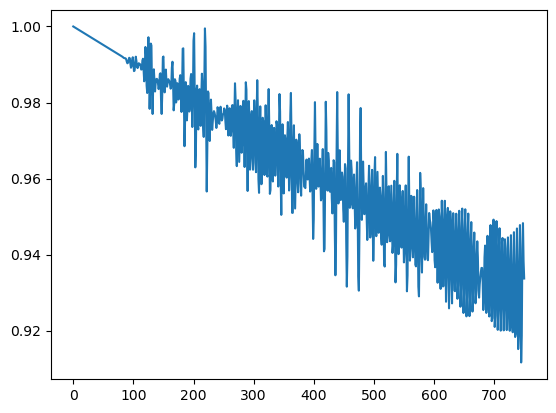

In [366]:
obs = solve(params).ys[:,-1]
pd.Series(obs).plot()

In [251]:
def quality(params):
    sol = solve(params)
    return jnp.where(diffrax.is_successful(sol.result),jnp.mean((sol.ys[:,-1]-obs)**2), 1e9)
    return jnp.mean((sol.ys[:,-1]-obs)**2)
    #return jnp.sqrt(jnp.mean((sol.ys[:,1]-obs)**2.0))

In [252]:
qgrad = jit(grad(quality))

In [254]:
%%time
x = np.array(qgrad(jnp.linspace(0.1,0.4,N)))

CPU times: total: 109 ms
Wall time: 95.9 ms


In [255]:
jsolve = jit(solve)

In [256]:
jqual = jit(quality)

In [257]:
import optax

In [355]:
opt = optax.adam(1e-2)
#opt = optax.optimistic_adam(1e-1)
#opt = optax.optimistic_gradient_descent(1e-2)
cparams = np.random.normal(np.ones_like(params)*0.3,0.1)
cparams = optax.projections.projection_non_negative(cparams)
state = opt.init(cparams)


In [358]:

state = opt.init(cparams)

for i in range(100):
    lgrad = qgrad(cparams)
    updates, state = opt.update(lgrad, state)
    cparams = optax.apply_updates(cparams, updates)
    cparams = optax.projections.projection_non_negative(cparams)
print(jqual(cparams))

1.6966770878590176e-05


<Axes: >

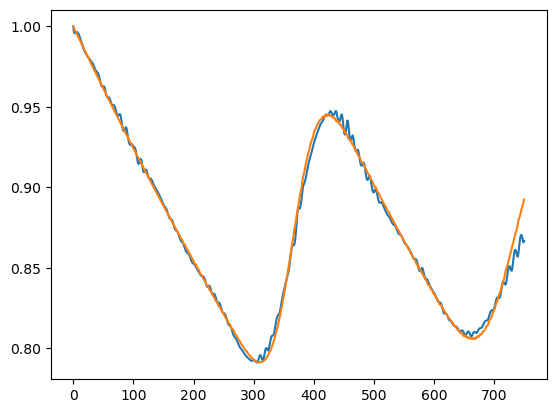

In [359]:
pd.Series(jsolve(cparams).ys[:,-1]).plot()
pd.Series(obs).plot()

<Axes: >

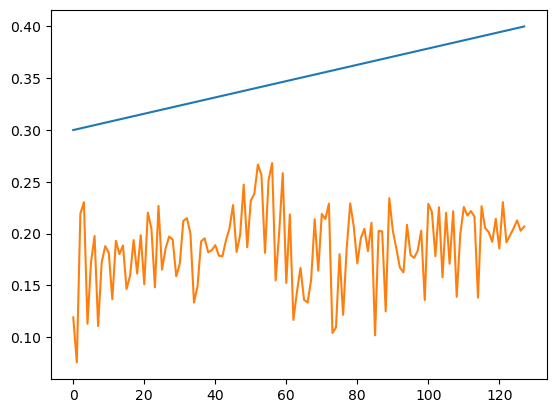

In [360]:
pd.Series(params).plot()
pd.Series(cparams).plot()

In [192]:
quality(Params(0.01,0.1, 2.0))

Array(0.02923102, dtype=float64)

In [193]:
jit(grad(jnp.sqrt))(0.0)

Array(inf, dtype=float64, weak_type=True)

In [194]:
jgrad = jit(grad(quality))

In [195]:
params

Params(cr=0.001, rr=0.01, sscale=2.9)

In [198]:
%%time
jgrad(Params(0.001,0.010001,2.90001))

CPU times: total: 0 ns
Wall time: 1.43 ms


Params(cr=Array(-0.00075457, dtype=float64, weak_type=True), rr=Array(0.00042577, dtype=float64, weak_type=True), sscale=Array(-6.82424911e-07, dtype=float64, weak_type=True))

In [179]:
jgrad(Params(0.01,0.1, 2.2))

Params(cr=Array(0.9567042, dtype=float64, weak_type=True), rr=Array(0.06722984, dtype=float64, weak_type=True), sscale=Array(0.00500273, dtype=float64, weak_type=True))

In [131]:
jsolve = jit(solve)

<Axes: >

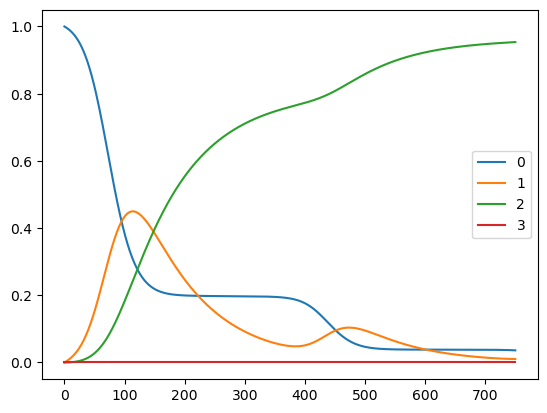

In [138]:
params = Params(0.001,0.01, 2.9)
sol = jsolve(params)
pd.DataFrame(sol.ys,index=sol.ts).plot()

In [110]:
jax.make_jaxpr(thing)(0.0, comp_vals, params)

{ lambda a:i32[4,2]; b:f32[] c:f32[4] d:f32[] e:f32[] f:f32[]. let
    g:f32[] = mul 6.283185307179586 b
    h:f32[] = div g 365.25
    i:f32[] = sin h
    j:f32[] = mul f i
    k:f32[] = exp j
    l:f32[] = mul d k
    m:f32[] = convert_element_type[new_dtype=float32 weak_type=False] l
    n:f32[] = convert_element_type[new_dtype=float32 weak_type=False] e
    o:f32[1] = broadcast_in_dim[
      broadcast_dimensions=()
      shape=(1,)
      sharding=None
    ] m
    p:f32[1] = broadcast_in_dim[
      broadcast_dimensions=()
      shape=(1,)
      sharding=None
    ] n
    q:f32[2] = concatenate[dimension=0] o p
    r:f32[] = convert_element_type[new_dtype=float32 weak_type=False] l
    s:f32[] = convert_element_type[new_dtype=float32 weak_type=False] e
    t:f32[1] = broadcast_in_dim[
      broadcast_dimensions=()
      shape=(1,)
      sharding=None
    ] r
    u:f32[1] = broadcast_in_dim[
      broadcast_dimensions=()
      shape=(1,)
      sharding=None
    ] s
    v:f32[2] = conca